# Decision Trees Project

## GraphX Labs ML Concepts Portfolio

In this notebook, we will build an intuitive Decision Tree classifier using the UCI Bank Marketing dataset.

The business question:

> Can we predict whether a customer will subscribe to a bank term deposit?

We will focus on both modeling and intuition: splits, Gini impurity, entropy, depth, overfitting, pruning, feature importance, and classification evaluation.

## 1. Problem Statement

Banks often run marketing campaigns to promote term deposits. Calling every customer can be expensive and inefficient.

Our goal is to build a model that estimates whether a customer is likely to subscribe, so marketing teams can prioritize outreach more intelligently.

## 2. Why Decision Trees?

Decision Trees feel natural because they mimic human decision-making.

A tree asks a question, follows the answer, and asks another question. Eventually, it reaches a final prediction.

Decision Trees are:

- easy to visualize
- easy to explain to stakeholders
- useful for nonlinear relationships
- great for learning how models split data

But they can also overfit if we let them grow without control.

## 3. Dataset Overview

Dataset source: UCI Machine Learning Repository, Bank Marketing Dataset.

The dataset contains marketing campaign records from a Portuguese banking institution.

Target variable:

- original column: `y`
- processed target: `subscribed`
- `1`: customer subscribed
- `0`: customer did not subscribe

We remove `duration` from the processed data because it is only known after the phone call ends. Keeping it would leak future information into a realistic pre-call prediction model.

## 4. Import Libraries

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree

sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd().parent
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = Path.cwd()

sys.path.append(str(PROJECT_ROOT))

DATA_RAW = PROJECT_ROOT / "data" / "raw" / "bank-additional" / "bank-additional-full.csv"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed" / "bank_marketing_processed.csv"
IMAGE_DIR = PROJECT_ROOT / "images"
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

## 5. Load Dataset

In [2]:
raw_df = pd.read_csv(DATA_RAW, sep=";")
raw_df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## 6. Initial Data Inspection

In [3]:
print("Shape:", raw_df.shape)
display(raw_df.head())
display(raw_df.describe(include="all").T.head(20))

Shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,41188.0,NaN,NaN,NaN,40.02406,10.42125,17.0,32.0,38.0,47.0,98.0
job,41188,12,admin.,10422,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,41188,4,married,24928,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,41188,8,university.degree,12168,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,41188,3,no,32588,NaN,NaN,NaN,NaN,NaN,NaN,NaN
housing,41188,3,yes,21576,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,41188,3,no,33950,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,41188,2,cellular,26144,NaN,NaN,NaN,NaN,NaN,NaN,NaN
month,41188,10,may,13769,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day_of_week,41188,5,thu,8623,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [5]:
missing_values = raw_df.isna().sum().sort_values(ascending=False)
duplicates = raw_df.duplicated().sum()
target_distribution = raw_df["y"].value_counts(normalize=True).rename("proportion")

print("Missing values:")
display(missing_values[missing_values > 0])
print("Duplicate rows:", duplicates)
display(target_distribution)

Missing values:


Series([], dtype: int64)

Duplicate rows: 12


no     0.887346
yes    0.112654
Name: proportion, dtype: float64

## 7. Exploratory Data Analysis

We explore the target balance first because classification metrics depend heavily on class distribution.

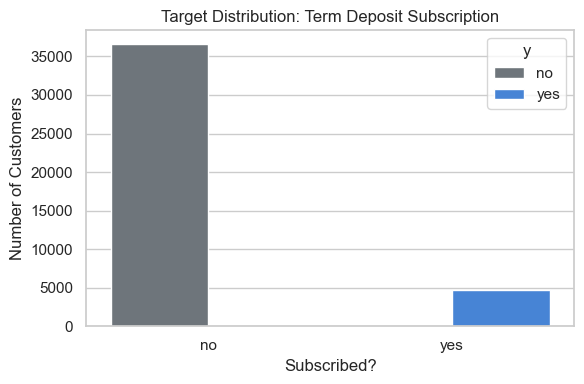

In [6]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=raw_df, x="y", hue="y", palette=["#6C757D", "#2F80ED"])
ax.set_title("Target Distribution: Term Deposit Subscription")
ax.set_xlabel("Subscribed?")
ax.set_ylabel("Number of Customers")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "target_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

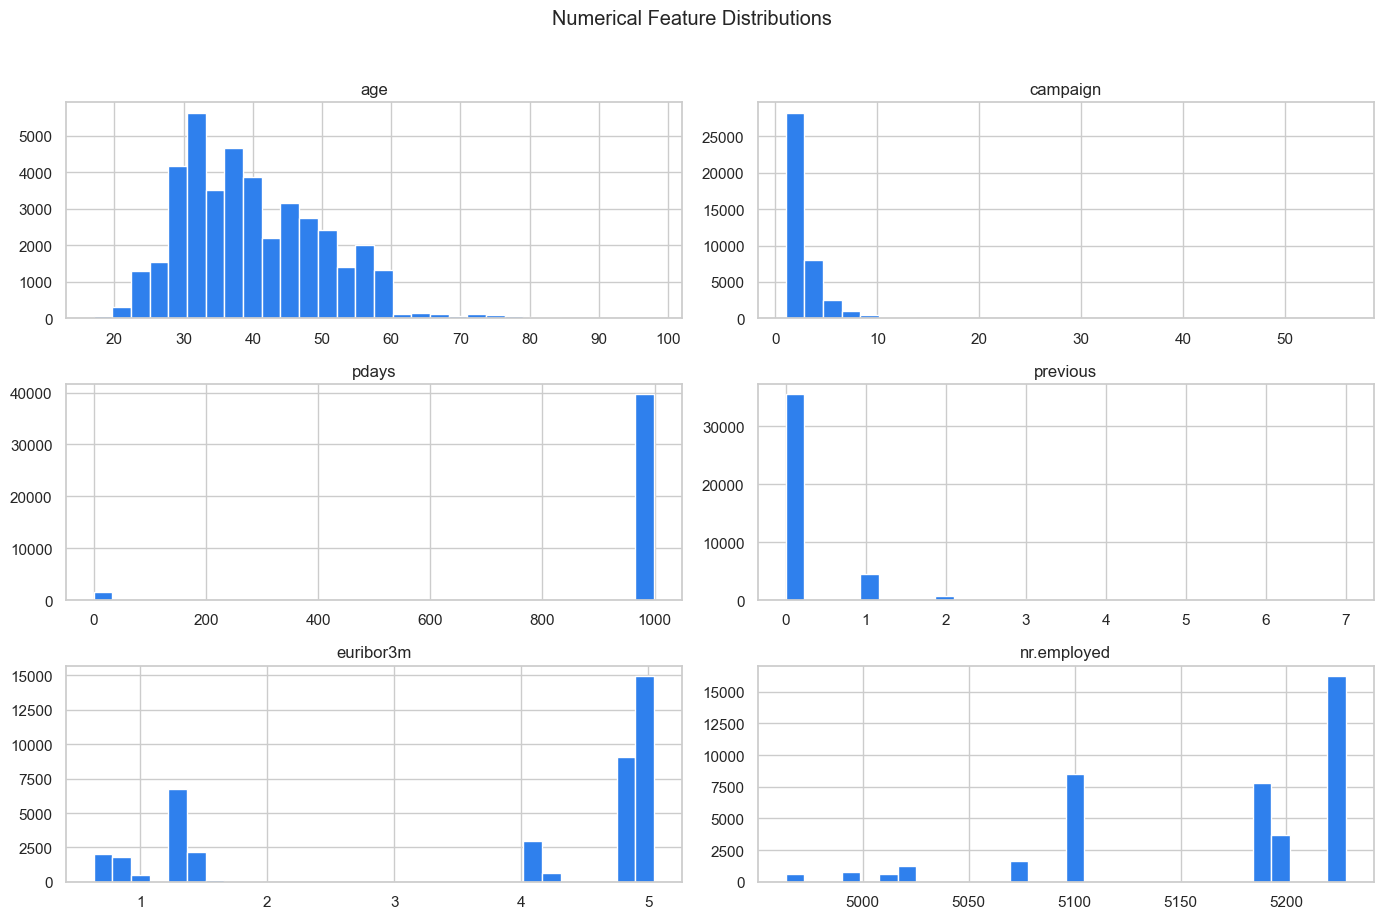

In [7]:
numerical_columns = raw_df.select_dtypes(include=["int64", "float64"]).columns.tolist()
selected_numerical = ["age", "campaign", "pdays", "previous", "euribor3m", "nr.employed"]

raw_df[selected_numerical].hist(figsize=(14, 9), bins=30, color="#2F80ED", edgecolor="white")
plt.suptitle("Numerical Feature Distributions", y=1.02)
plt.tight_layout()
plt.savefig(IMAGE_DIR / "numerical_feature_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

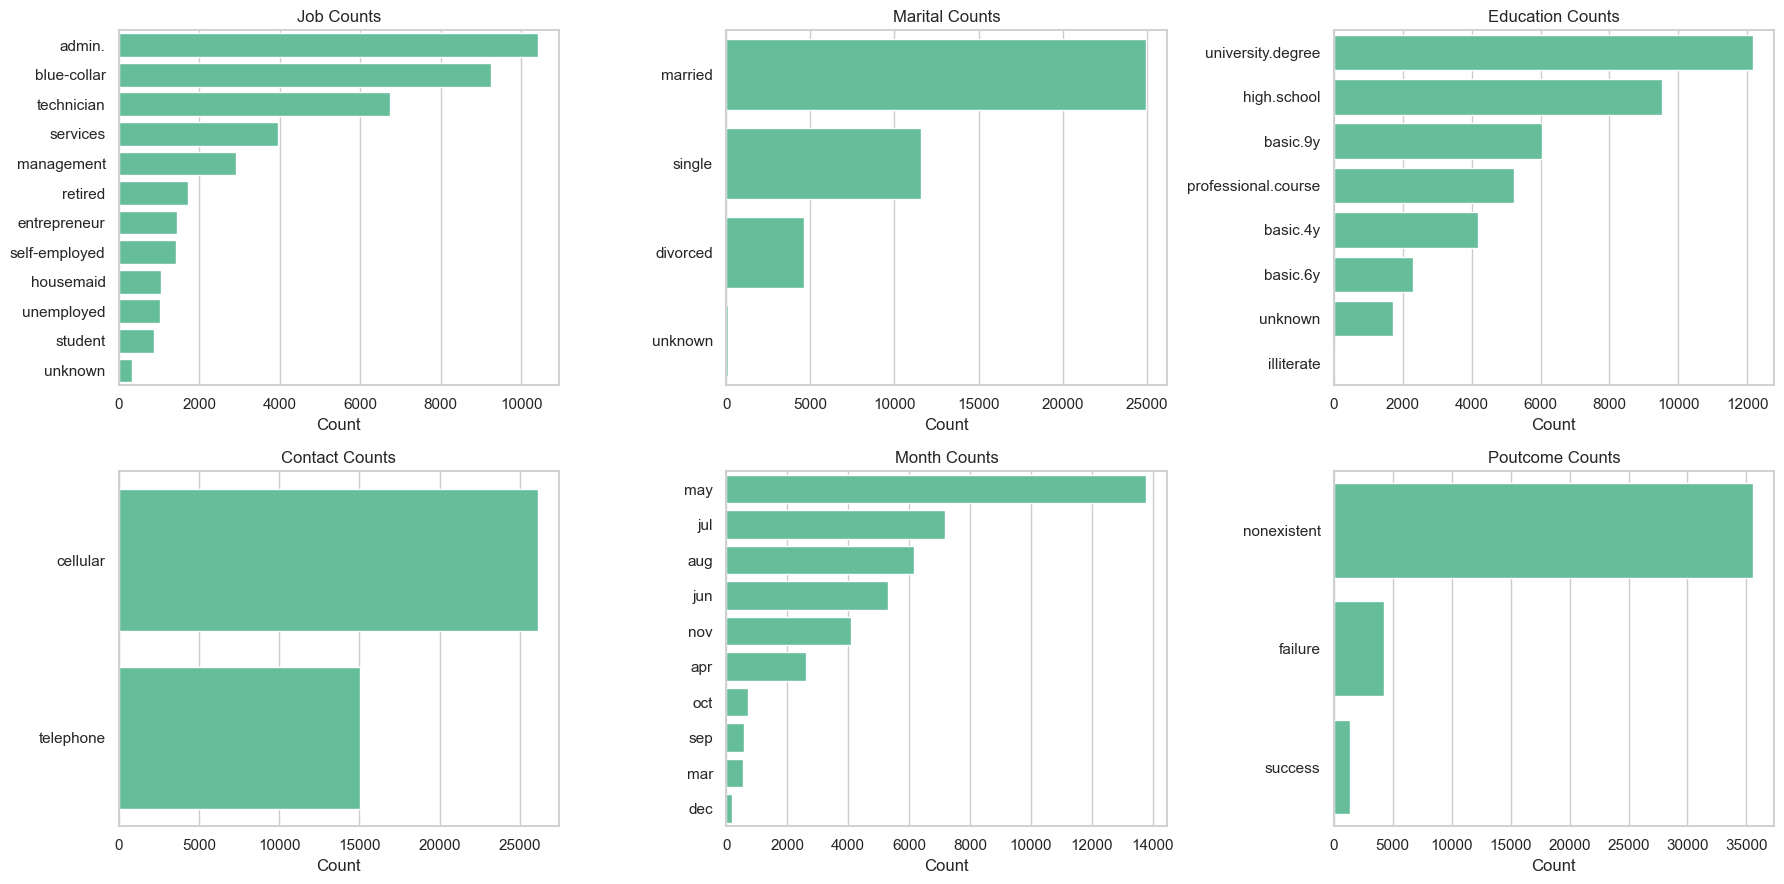

In [8]:
categorical_columns = ["job", "marital", "education", "contact", "month", "poutcome"]

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()

for ax, column in zip(axes, categorical_columns):
    order = raw_df[column].value_counts().index
    sns.countplot(data=raw_df, y=column, order=order, ax=ax, color="#56CC9D")
    ax.set_title(f"{column.title()} Counts")
    ax.set_xlabel("Count")
    ax.set_ylabel("")

plt.tight_layout()
plt.savefig(IMAGE_DIR / "categorical_feature_counts.png", dpi=300, bbox_inches="tight")
plt.show()

/var/folders/7h/yh12knpx2lsgzzfbqc5zkl500000gn/T/ipykernel_51647/281461712.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=raw_df, x="poutcome", y=(raw_df["y"] == "yes").astype(int), ax=axes[0], ci=None, color="#2F80ED")
/var/folders/7h/yh12knpx2lsgzzfbqc5zkl500000gn/T/ipykernel_51647/281461712.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=raw_df, x="contact", y=(raw_df["y"] == "yes").astype(int), ax=axes[1], ci=None, color="#56CC9D")
/var/folders/7h/yh12knpx2lsgzzfbqc5zkl500000gn/T/ipykernel_51647/281461712.py:11: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=raw_df, x="month", y=(raw_df["y"] == "yes").astype(int), ax=axes[2], ci=None, color="#F2C94C")


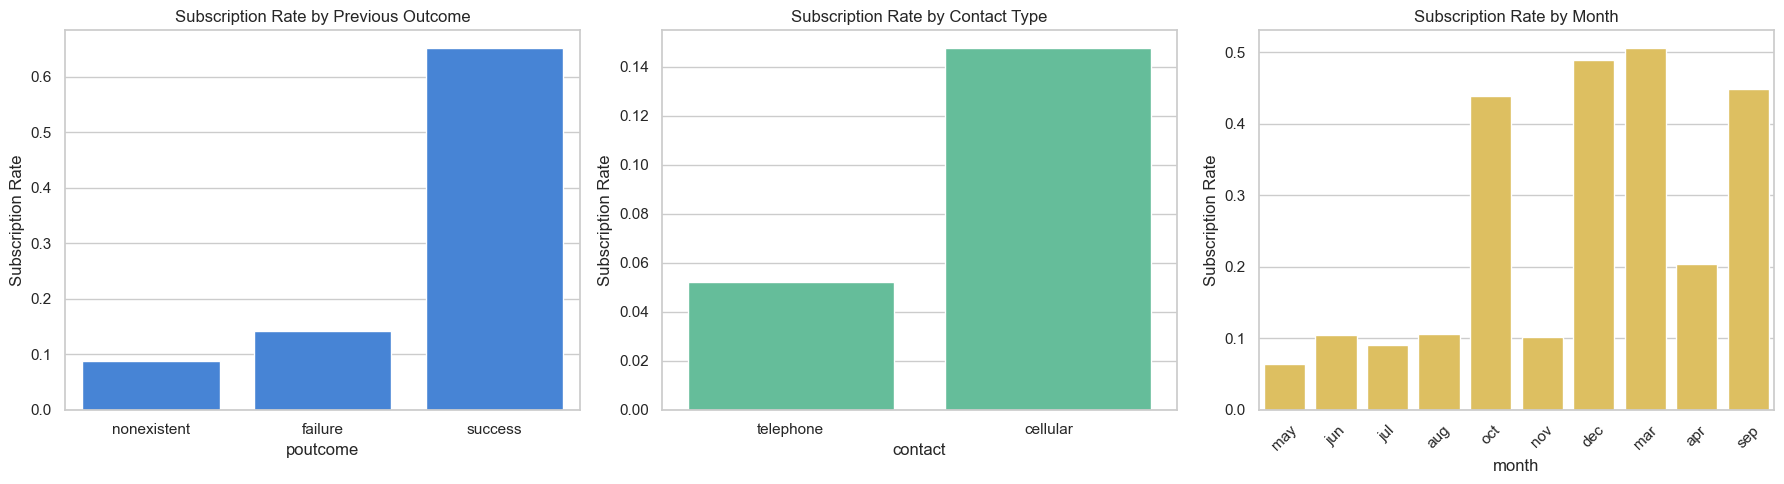

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=raw_df, x="poutcome", y=(raw_df["y"] == "yes").astype(int), ax=axes[0], ci=None, color="#2F80ED")
axes[0].set_title("Subscription Rate by Previous Outcome")
axes[0].set_ylabel("Subscription Rate")

sns.barplot(data=raw_df, x="contact", y=(raw_df["y"] == "yes").astype(int), ax=axes[1], ci=None, color="#56CC9D")
axes[1].set_title("Subscription Rate by Contact Type")
axes[1].set_ylabel("Subscription Rate")

sns.barplot(data=raw_df, x="month", y=(raw_df["y"] == "yes").astype(int), ax=axes[2], ci=None, color="#F2C94C")
axes[2].set_title("Subscription Rate by Month")
axes[2].set_ylabel("Subscription Rate")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(IMAGE_DIR / "feature_relationships.png", dpi=300, bbox_inches="tight")
plt.show()

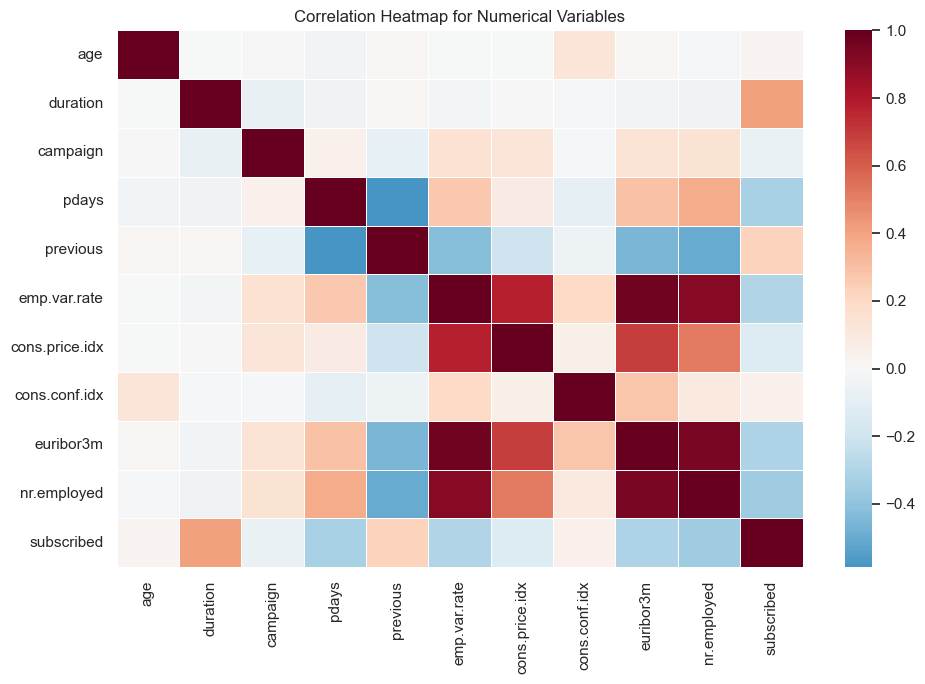

In [10]:
corr_df = raw_df.copy()
corr_df["subscribed"] = (corr_df["y"] == "yes").astype(int)

plt.figure(figsize=(10, 7))
sns.heatmap(
    corr_df.select_dtypes(include=["int64", "float64"]).corr(),
    cmap="RdBu_r",
    center=0,
    annot=False,
    linewidths=0.5,
)
plt.title("Correlation Heatmap for Numerical Variables")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

## 8. Data Cleaning

In [11]:
df = raw_df.copy()
df.columns = (
    df.columns.str.strip()
    .str.lower()
    .str.replace(".", "_", regex=False)
    .str.replace(" ", "_", regex=False)
)

df = df.drop_duplicates().copy()
df["subscribed"] = df["y"].map({"yes": 1, "no": 0})
df = df.drop(columns=["y"])

if "duration" in df.columns:
    df = df.drop(columns=["duration"])

print("Cleaned shape:", df.shape)
display(df.head())

Cleaned shape: (41176, 20)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,subscribed
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0


In [12]:
DATA_PROCESSED.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(DATA_PROCESSED, index=False)
print("Saved processed data to:", DATA_PROCESSED)

Saved processed data to: /Users/meenakshijayaraj/Desktop/graphx-ml-concepts-portfolio/decision-trees/data/processed/bank_marketing_processed.csv


## 9. Feature Engineering

Decision Trees in scikit-learn need numeric inputs, so we one-hot encode categorical columns.

Scaling is not required for Decision Trees because the model splits on feature thresholds. It does not use distance calculations like KNN or coefficient optimization like Logistic Regression.

In [13]:
X = df.drop(columns=["subscribed"])
y = df["subscribed"]

categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical features:", categorical_features)
print("Numerical features:", numerical_features)

X_encoded = pd.get_dummies(X, columns=categorical_features, drop_first=True)
print("Encoded feature shape:", X_encoded.shape)

Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Numerical features: ['age', 'campaign', 'pdays', 'previous', 'emp_var_rate', 'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'nr_employed']
Encoded feature shape: (41176, 52)


## 10. Train-Test Split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("Positive class rate in train:", y_train.mean().round(4))
print("Positive class rate in test:", y_test.mean().round(4))

X_train: (32940, 52)
X_test: (8236, 52)
Positive class rate in train: 0.1127
Positive class rate in test: 0.1127


## 11. Build Baseline Decision Tree Model

In [15]:
baseline_tree = DecisionTreeClassifier(
    criterion="gini",
    random_state=RANDOM_STATE
)

baseline_tree.fit(X_train, y_train)
baseline_predictions = baseline_tree.predict(X_test)
baseline_probabilities = baseline_tree.predict_proba(X_test)[:, 1]

## 12. Model Evaluation

In [16]:
def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    test_prob = model.predict_proba(X_test)[:, 1]

    metrics = {
        "model": name,
        "train_accuracy": accuracy_score(y_train, train_pred),
        "test_accuracy": accuracy_score(y_test, test_pred),
        "precision": precision_score(y_test, test_pred, zero_division=0),
        "recall": recall_score(y_test, test_pred, zero_division=0),
        "f1": f1_score(y_test, test_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, test_prob),
    }
    return metrics

baseline_metrics = evaluate_model("Baseline Decision Tree", baseline_tree, X_train, y_train, X_test, y_test)
pd.DataFrame([baseline_metrics])

,model,train_accuracy,test_accuracy,precision,recall,f1,roc_auc
0,Baseline Decision Tree,0.995173,0.839,0.301793,0.326509,0.313665,0.617698


In [17]:
print(classification_report(y_test, baseline_predictions, target_names=["No", "Yes"], zero_division=0))

              precision    recall  f1-score   support

          No       0.91      0.90      0.91      7308
         Yes       0.30      0.33      0.31       928

    accuracy                           0.84      8236
   macro avg       0.61      0.62      0.61      8236
weighted avg       0.84      0.84      0.84      8236



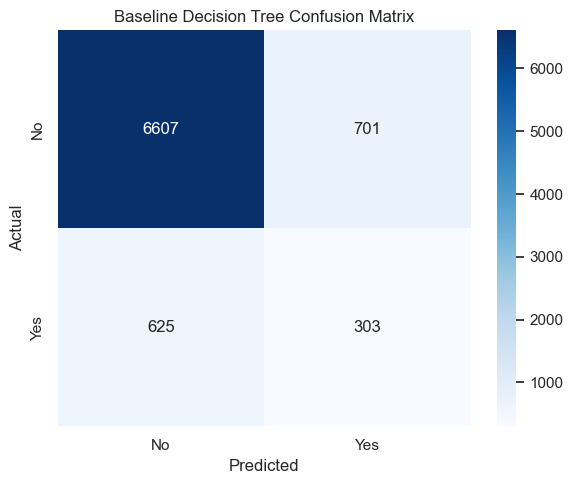

In [18]:
cm = confusion_matrix(y_test, baseline_predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No", "Yes"], yticklabels=["No", "Yes"])
plt.title("Baseline Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

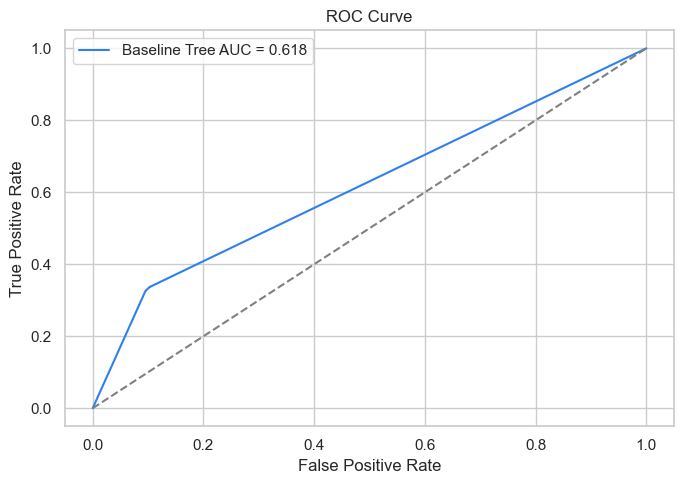

In [19]:
fpr, tpr, _ = roc_curve(y_test, baseline_probabilities)
baseline_auc = roc_auc_score(y_test, baseline_probabilities)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Baseline Tree AUC = {baseline_auc:.3f}", color="#2F80ED")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.savefig(IMAGE_DIR / "roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

## 13. Visualizing the Decision Tree

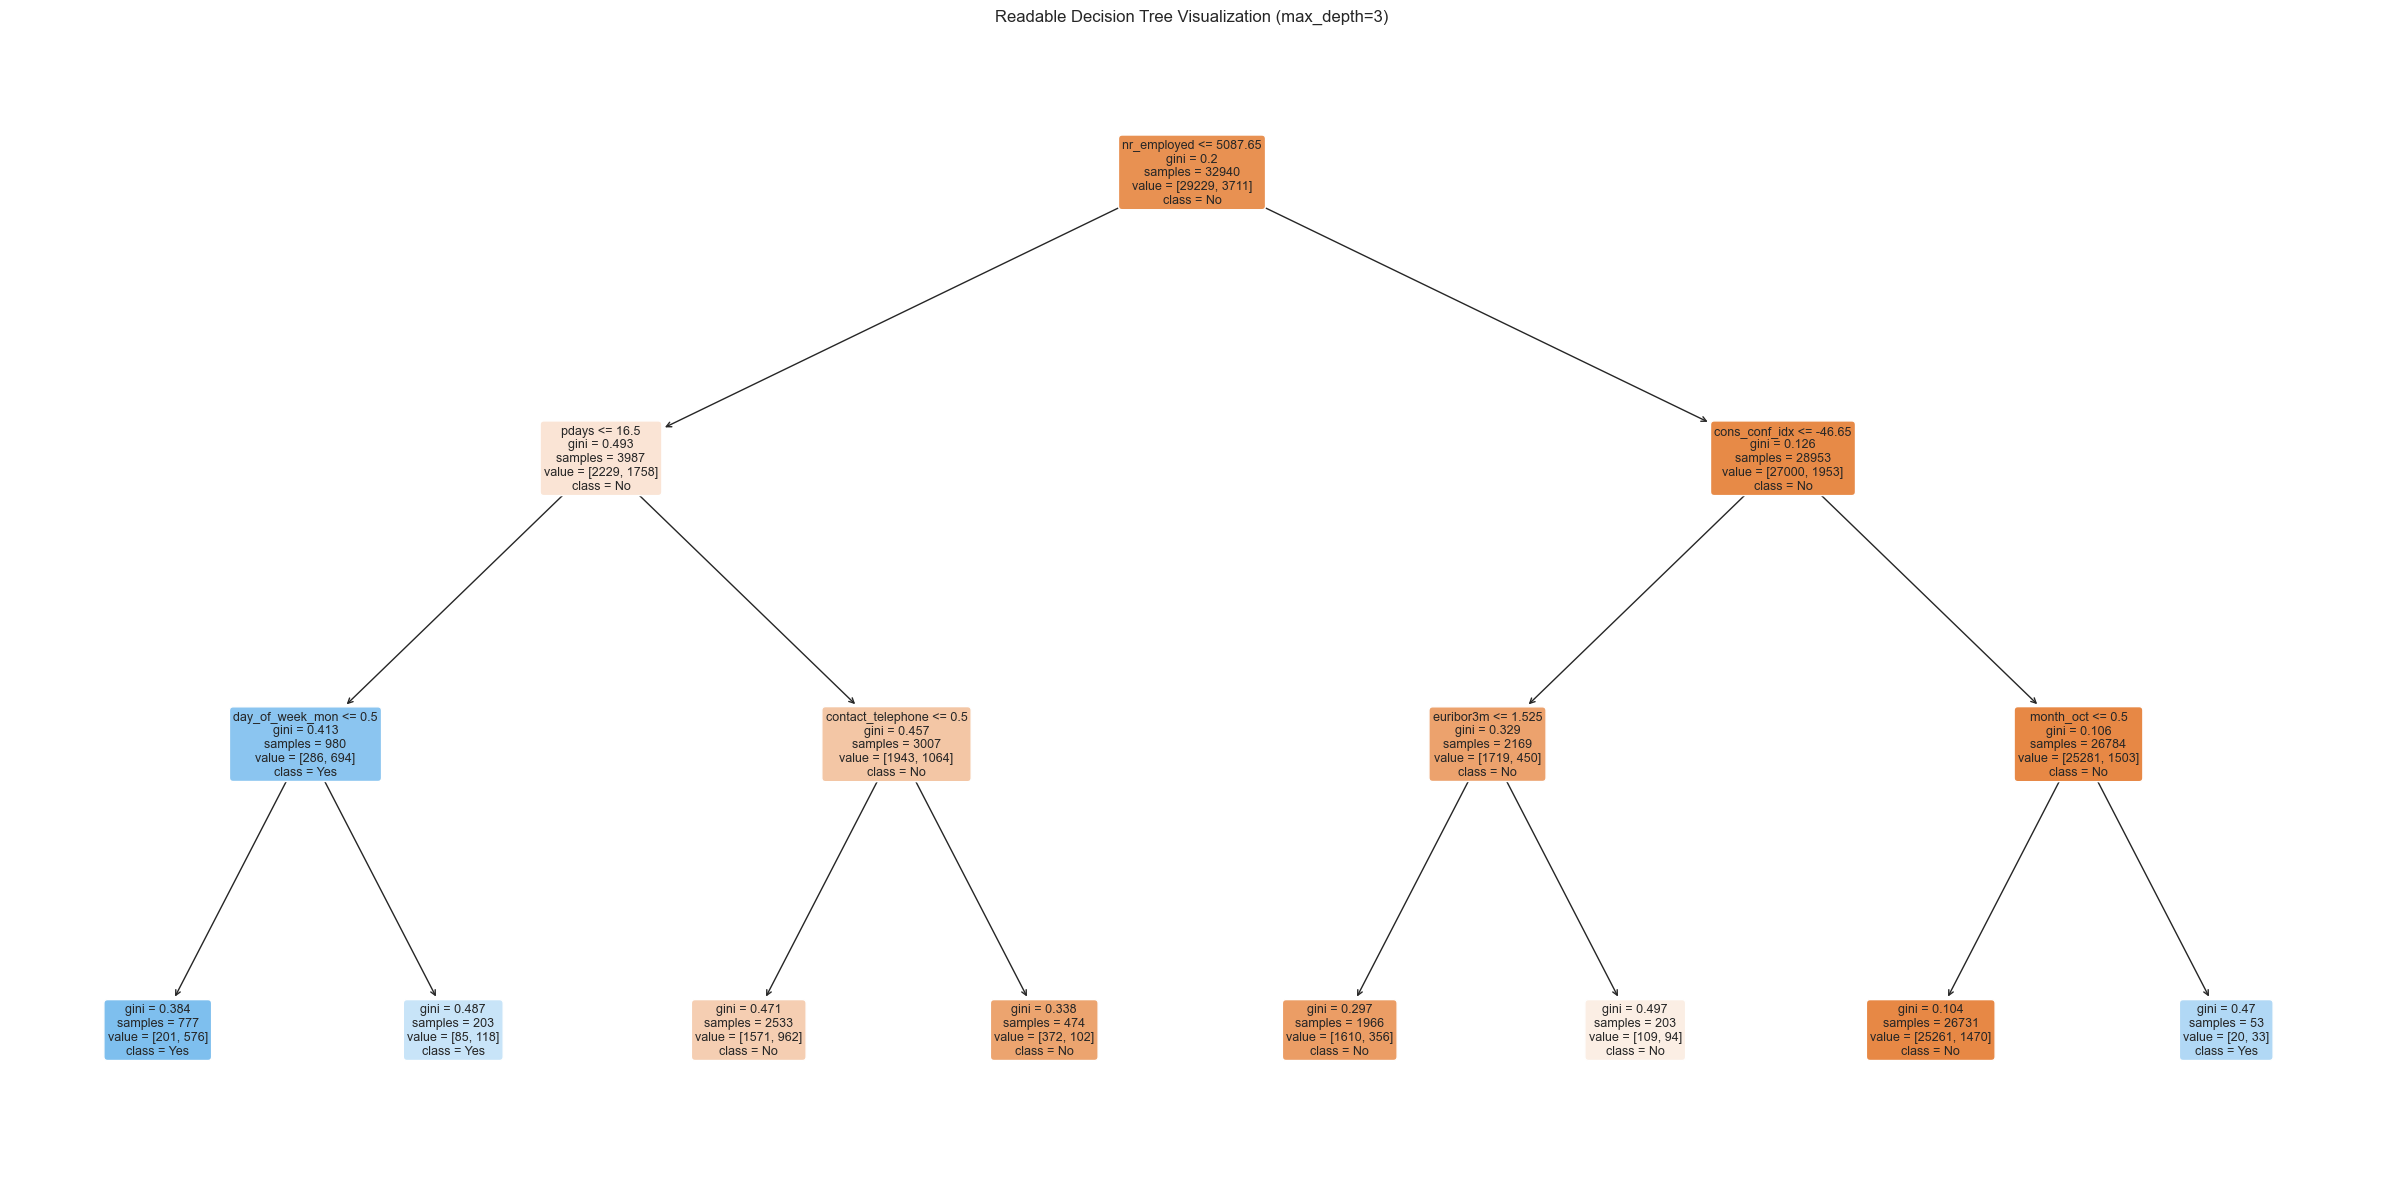

In [20]:
shallow_visual_tree = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    min_samples_leaf=50,
    random_state=RANDOM_STATE
)
shallow_visual_tree.fit(X_train, y_train)

plt.figure(figsize=(24, 12))
plot_tree(
    shallow_visual_tree,
    feature_names=X_encoded.columns,
    class_names=["No", "Yes"],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Readable Decision Tree Visualization (max_depth=3)")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "decision_tree_visualization.png", dpi=300, bbox_inches="tight")
plt.show()

## 14. Understanding Feature Importance

,feature,importance
0,age,0.168558
8,nr_employed,0.155406
7,euribor3m,0.097242
1,campaign,0.083379
2,pdays,0.040892
33,housing_yes,0.038925
35,loan_yes,0.033414
6,cons_conf_idx,0.022411
20,marital_married,0.020234
21,marital_single,0.019536


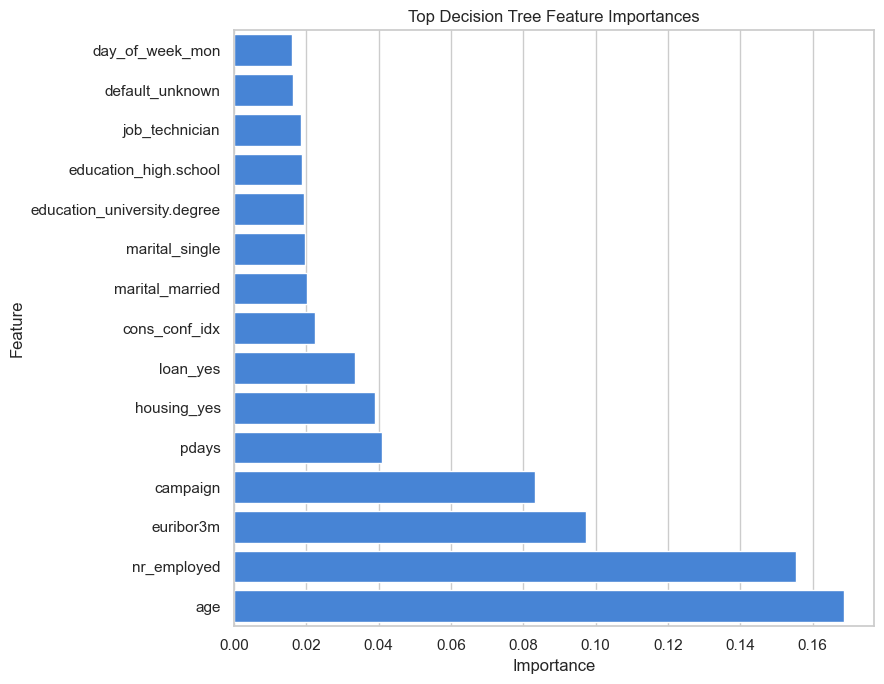

In [21]:
importance_df = pd.DataFrame({
    "feature": X_encoded.columns,
    "importance": baseline_tree.feature_importances_
}).sort_values("importance", ascending=False)

display(importance_df.head(15))

plt.figure(figsize=(9, 7))
top_importance = importance_df.head(15).sort_values("importance")
sns.barplot(data=top_importance, x="importance", y="feature", color="#2F80ED")
plt.title("Top Decision Tree Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

## 15. Overfitting in Decision Trees

In [22]:
unrestricted_tree = DecisionTreeClassifier(random_state=RANDOM_STATE)
unrestricted_tree.fit(X_train, y_train)

shallow_tree = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=100,
    random_state=RANDOM_STATE
)
shallow_tree.fit(X_train, y_train)

overfitting_comparison = pd.DataFrame([
    evaluate_model("Unrestricted Tree", unrestricted_tree, X_train, y_train, X_test, y_test),
    evaluate_model("Shallow Tree", shallow_tree, X_train, y_train, X_test, y_test),
])

overfitting_comparison

,model,train_accuracy,test_accuracy,precision,recall,f1,roc_auc
0,Unrestricted Tree,0.995173,0.839000,0.301793,0.326509,0.313665,0.617698
1,Shallow Tree,0.899727,0.898494,0.693277,0.177802,0.283019,0.785563


A deep tree usually has much higher training accuracy than test accuracy. That gap is the warning sign.

The shallow tree gives up some training perfection, but it is easier to explain and often generalizes better.

## 16. Pruning / Regularization

In [23]:
param_grid = {
    "max_depth": [3, 4, 5, 6, 8],
    "min_samples_split": [50, 100, 250],
    "min_samples_leaf": [25, 50, 100],
    "criterion": ["gini", "entropy"],
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV ROC-AUC:", round(grid_search.best_score_, 4))

Best parameters: {'criterion': 'entropy', 'max_depth': 8, 'min_samples_leaf': 25, 'min_samples_split': 250}
Best CV ROC-AUC: 0.7876


In [24]:
pruning_path = DecisionTreeClassifier(random_state=RANDOM_STATE).cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = pruning_path.ccp_alphas
print("Number of candidate ccp_alpha values:", len(ccp_alphas))
print("Small candidate alphas:", ccp_alphas[:5])

Number of candidate ccp_alpha values: 1432
Small candidate alphas: [0.00000000e+00 0.00000000e+00 2.02388181e-06 2.02388181e-06
 3.03582271e-06]


## 17. Final Model

In [25]:
final_tree = grid_search.best_estimator_

final_predictions = final_tree.predict(X_test)
final_probabilities = final_tree.predict_proba(X_test)[:, 1]

final_metrics = evaluate_model("Final Regularized Tree", final_tree, X_train, y_train, X_test, y_test)
results_df = pd.DataFrame([baseline_metrics, final_metrics])
results_df

,model,train_accuracy,test_accuracy,precision,recall,f1,roc_auc
0,Baseline Decision Tree,0.995173,0.839000,0.301793,0.326509,0.313665,0.617698
1,Final Regularized Tree,0.903279,0.900437,0.635678,0.272629,0.381599,0.801996


In [26]:
print(classification_report(y_test, final_predictions, target_names=["No", "Yes"], zero_division=0))

              precision    recall  f1-score   support

          No       0.91      0.98      0.95      7308
         Yes       0.64      0.27      0.38       928

    accuracy                           0.90      8236
   macro avg       0.77      0.63      0.66      8236
weighted avg       0.88      0.90      0.88      8236



## 18. Final Insights

In business language, the final Decision Tree learned that campaign response is shaped by a combination of:

- previous campaign behavior
- contact strategy
- customer profile
- macroeconomic conditions

The most important modeling lesson is that the biggest tree is not automatically the best tree. A regularized tree is more useful because it balances performance with interpretability.

## 19. Limitations

Decision Trees are intuitive, but they are not perfect.

Key limitations:

- they can overfit easily
- small data changes can produce a different tree
- class imbalance affects evaluation
- single trees often underperform Random Forest or Gradient Boosting
- feature importance does not prove causation

## 20. Interview Questions

A few key questions to review:

- What is a Decision Tree?
- What is Gini impurity?
- What is entropy?
- What is information gain?
- Why do Decision Trees overfit?
- How do `max_depth`, `min_samples_split`, and `min_samples_leaf` help?
- Do Decision Trees need feature scaling?
- How do you explain feature importance?

See the full companion file:

`decision-trees/interview_questions.md`